In [1]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import os


In [2]:
# Step 2: Load the dataset
os.chdir("C:/Users/Srinivasan/Desktop/Madurai/ml-portfolio/01-linear-regression/data")
print(os.getcwd())
df = pd.read_csv('house.csv')
df.head()


C:\Users\Srinivasan\Desktop\Madurai\ml-portfolio\01-linear-regression\data


,Area,Bedrooms,Bathrooms,Material,Locality,Price
0,1790,2,2,Concrete,Riverside,114300
1,2030,4,2,Concrete,Riverside,114200
2,1740,3,2,Concrete,Riverside,114800
3,1980,3,2,Concrete,Riverside,94700
4,2130,3,3,Concrete,Riverside,119800


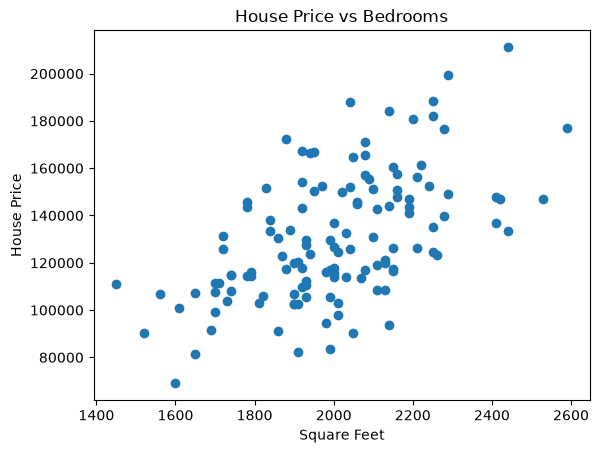

In [70]:
plt.scatter(df["Area"], df["Price"])
plt.xlabel("Square Feet")
plt.ylabel("House Price")
plt.title("House Price vs Bedrooms")
plt.show()

In [73]:
# Step 3: Select Feature and Target
# We will use only 'Area' to predict 'Price'
X = df[['Area']]
y = df['Price']

type(X)


pandas.DataFrame

In [39]:
X

,Area
0,1790
1,2030
2,1740
3,1980
4,2130
...,...
123,1900
124,2160
125,2070
126,2020


In [40]:
y

0      114300
1      114200
2      114800
3       94700
4      119800
        ...  
123    119700
124    147900
125    113500
126    149900
127    124600
Name: Price, Length: 128, dtype: int64

In [41]:
# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


In [42]:
X_train

,Area
126,2020
24,2210
67,2040
111,1740
89,2010
...,...
106,2130
14,2590
92,2110
51,1860


In [43]:
# Step 5: Train the model
model = LinearRegression()
model.fit(X_train, y_train)
# model = LinearRegression().fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[74.93]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Area']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.898e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [44]:
model.intercept_

np.float64(-18984.40156145551)

In [45]:
model.coef_

array([74.92694108])

In [46]:
# Price of house = -18984.40156145548 + 74.92694108*Area

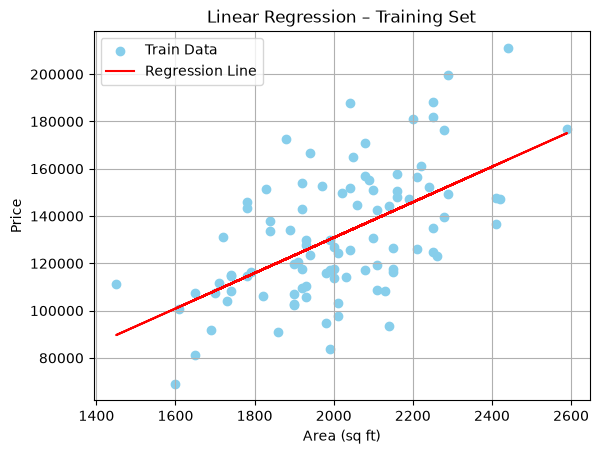

In [47]:
# Step 6: Visualize regression line on training data
plt.scatter(X_train, y_train, color='skyblue', label='Train Data')
plt.plot(X_train, model.predict(X_train), color='red', label='Regression Line')
plt.xlabel('Area (sq ft)')
plt.ylabel('Price')
plt.title('Linear Regression – Training Set')
plt.legend()
plt.grid(True)
plt.show()


In [48]:
# Step 7: Evaluate model on train and test sets

# On Training Data
train_preds = model.predict(X_train)


In [49]:
train_preds

array([132368.01941075, 146604.13821507, 133866.55823226, 111388.47590966,
       131618.75      , 114385.55355267, 151849.02409034, 107642.12885589,
       126373.86412473,  89659.6629978 , 128621.67235699, 149601.21585808,
       147353.40762582, 125624.59471397, 110639.2064989 , 151849.02409034,
       146604.13821507, 152598.2935011 , 123376.78648171, 100898.70415911,
       130869.48058925, 142108.52175055, 138362.17469678, 114385.55355267,
       141359.2523398 , 133866.55823226, 111388.47590966, 108391.39826664,
       136863.63587527, 145105.59939356, 135365.09705377, 130869.48058925,
       149601.21585808, 142857.7911613 , 124875.32530322, 125624.59471397,
       126373.86412473, 130120.21117849, 139111.44410754, 142108.52175055,
       136863.63587527, 129370.94176774, 130120.21117849, 109889.93708815,
       104645.05121287, 131618.75      , 118131.90060644, 161589.52643014,
       109140.66767739, 124875.32530322, 104645.05121287, 138362.17469678,
       124875.32530322, 1

In [50]:
print("Train R² Score:", r2_score(y_train, train_preds))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, train_preds)))
#print("Results")
# On Test Data
test_preds = model.predict(X_test)
print("Test R² Score:", r2_score(y_test, test_preds))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, test_preds)))


Train R² Score: 0.32875680616329306
Train RMSE: 22362.946915128254
Test R² Score: 0.19464215306124688
Test RMSE: 22219.314632146063


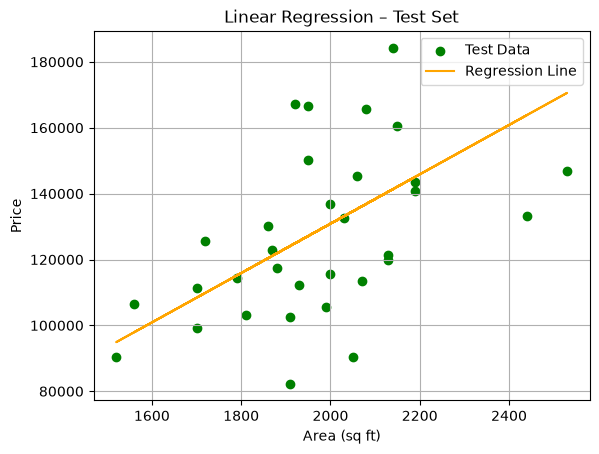

In [51]:
# Step 8: Visualize predictions on test data
plt.scatter(X_test, y_test, color='green', label='Test Data')
plt.plot(X_test, test_preds, color='orange', label='Regression Line')
plt.xlabel('Area (sq ft)')
plt.ylabel('Price')
plt.title('Linear Regression – Test Set')
plt.legend()
plt.grid(True)
plt.show()


In [52]:
#  Predict on test data
y_pred = model.predict(X_test)


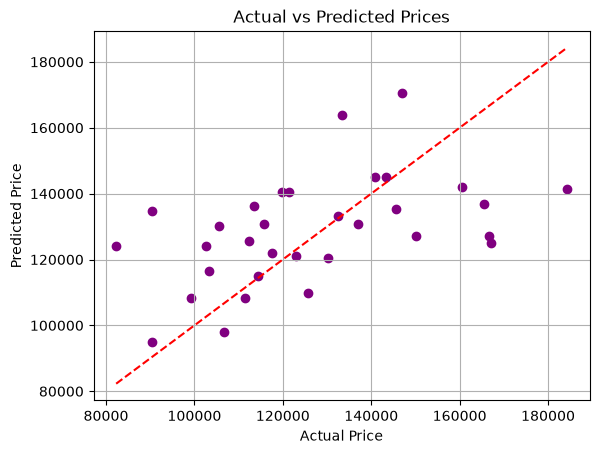

In [53]:
# Scatter Plot – Actual vs Predicted
plt.scatter(y_test, y_pred, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')  # Ideal line
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices')
plt.grid(True)
plt.show()


In [54]:
#  Calculate and Print R² and Coefficients

# R² Score
r2 = r2_score(y_test, y_pred)
print(f"R² Score on Test Data: {r2:.2f}")

# Coefficient and Intercept
print(f"Model Coefficient (slope): {model.coef_[0]:.2f}")
print(f"Model Intercept: {model.intercept_:.2f}")


R² Score on Test Data: 0.19
Model Coefficient (slope): 74.93
Model Intercept: -18984.40


In [55]:
#  Predict on test data
y_pred = model.predict(X_test)
y_pred

array([109889.93708815,  97901.62651609, 124875.32530322, 125624.59471397,
       135365.09705377, 145105.59939356, 136863.63587527, 124126.05589246,
       141359.2523398 , 130869.48058925, 142108.52175055, 108391.39826664,
       120379.7088387 , 140609.98292904, 163837.3346624 , 130869.48058925,
       121878.2476602 , 145105.59939356, 136114.36646452,  94904.54887308,
       108391.39826664, 133117.28882151, 127123.13353548, 121128.97824945,
       170580.75935918, 116633.36178493, 127123.13353548, 140609.98292904,
       134615.82764301, 115134.82296342, 124126.05589246, 130120.21117849])

In [56]:
y_pred_df = pd.DataFrame(y_pred,columns=['house_price_predicted'])
y_pred_df

,house_price_predicted
0,109889.937088
1,97901.626516
2,124875.325303
3,125624.594714
4,135365.097054
5,145105.599394
6,136863.635875
7,124126.055892
8,141359.252340
9,130869.480589


In [57]:
X_test.reset_index(drop=True)

,Area
0,1720
1,1560
2,1920
3,1930
4,2060
5,2190
6,2080
7,1910
8,2140
9,2000


In [58]:
y_pred_df.shape

(32, 1)

In [59]:
final_db = pd.concat([X_test.reset_index(drop=True),y_test.reset_index(drop=True),y_pred_df],axis=1)

In [60]:
final_db

,Area,Price,house_price_predicted
0,1720,125700,109889.937088
1,1560,106600,97901.626516
2,1920,167200,124875.325303
3,1930,112300,125624.594714
4,2060,145500,135365.097054
5,2190,140900,145105.599394
6,2080,165600,136863.635875
7,1910,82300,124126.055892
8,2140,184300,141359.252340
9,2000,137000,130869.480589


In [61]:
final_db['Error_pct'] = abs(final_db.Price - final_db.house_price_predicted)/final_db.Price

In [62]:
final_db

,Area,Price,house_price_predicted,Error_pct
0,1720,125700,109889.937088,0.125776
1,1560,106600,97901.626516,0.081598
2,1920,167200,124875.325303,0.253138
3,1930,112300,125624.594714,0.118652
4,2060,145500,135365.097054,0.069656
5,2190,140900,145105.599394,0.029848
6,2080,165600,136863.635875,0.173529
7,1910,82300,124126.055892,0.508215
8,2140,184300,141359.252340,0.232994
9,2000,137000,130869.480589,0.044748


In [63]:
final_db['Error_pct'].mean()

np.float64(0.14314133310025404)

In [64]:
# Accuracy rate 
1- final_db['Error_pct'].mean()

np.float64(0.856858666899746)